In [1]:
# Global Development Analysis:

# Objective:

# Analyze relationships between economic and social indicators across countries using World Bank data.

# Methodology 

# 1. Load datasets for:
#    - GDP per capita
#    - Life expectancy
#    - Population
#    - Inflation
#    - Unemployment

# 2. Clean datasets:
#    - Remove metadata rows
#    - Select relevant columns (Country, selected years)
#    - Standardize column names

# 3. Filter countries of interest:
#    - India
#    - United States
#    - China
#    - Germany
#    - Brazil

# 4. Merge datasets:
#    - Combine all indicators into a single dataset
#    - Align by country and year

# 5. Perform analysis:
#    - Time-series analysis (trend over years)
#    - Cross-country comparisons
#    - Relationship analysis (e.g., GDP vs Life Expectancy)

# 6. Visualize results:
#    - Line graphs for trends
#    - Bar charts for comparisons
#    - Scatter plots for relationships

# 7. Interpret findings:
#    - Identify patterns and correlations
#    - Relate economic indicators to social outcomes
       

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

def load_wb_data(file):
    df = pd.read_csv(file, skiprows=4)
    df = df[['Country Name', 'Country Code', '2000', '2005', '2010', '2015', '2020']]
    df.columns = ['Country', 'Code', '2000', '2005', '2010', '2015', '2020']
    return df

gdp = load_wb_data('gdp_per_capita.csv')
life = load_wb_data('life_expectancy.csv')
pop = load_wb_data('population.csv')
inflation = load_wb_data('inflation.csv')
unemp = load_wb_data('unemployment.csv')

In [3]:
countries = ['India', 'United States', 'China', 'Germany', 'Brazil']

def filter_df(df):
    return df[df['Country'].isin(countries)]

gdp = filter_df(gdp)
life = filter_df(life)
pop = filter_df(pop)
inflation = filter_df(inflation)
unemp = filter_df(unemp)

In [4]:
merged = gdp.copy()

merged = merged.merge(life, on=['Country','Code'], suffixes=('_gdp', '_life'))
merged = merged.merge(pop, on=['Country','Code'])
merged = merged.merge(inflation, on=['Country','Code'], suffixes=('', '_infl'))
merged = merged.merge(unemp, on=['Country','Code'], suffixes=('', '_unemp'))

merged.head()

,Country,Code,2000_gdp,2005_gdp,2010_gdp,2015_gdp,2020_gdp,2000_life,2005_life,2010_life,...,2000_infl,2005_infl,2010_infl,2015_infl,2020_infl,2000_unemp,2005_unemp,2010_unemp,2015_unemp,2020_unemp
0,Brazil,BRA,3766.547863,4827.781659,11403.284004,8936.195589,7074.194075,69.584000,71.832000,73.779000,...,7.044141,6.869537,5.038727,9.029901,3.211768,NaN,10.551,NaN,8.538,13.697
1,China,CHN,969.199514,1777.644968,4629.245517,8175.332851,10627.463799,72.288000,74.085000,75.668000,...,0.347811,1.776414,3.175325,1.437024,2.419422,3.707,4.200,4.100,NaN,5.610
2,Germany,DEU,23925.855990,35084.436355,42396.966598,41929.754911,47394.873450,77.926829,78.931707,79.987805,...,1.440268,1.546911,1.103810,0.514426,0.144878,7.917,11.193,7.043,4.612,3.881
3,India,IND,442.750219,710.488080,1347.519391,1583.998159,1907.042516,62.749000,64.939000,67.162000,...,4.009436,4.246344,11.989390,4.906973,6.623437,2.731,3.804,3.115,NaN,7.859
4,United States,USA,36329.956073,44123.407068,48642.610018,56572.918900,63515.949181,76.636585,77.487805,78.541463,...,3.376857,3.392747,1.640043,0.118627,1.233584,3.992,5.084,9.633,5.280,8.055


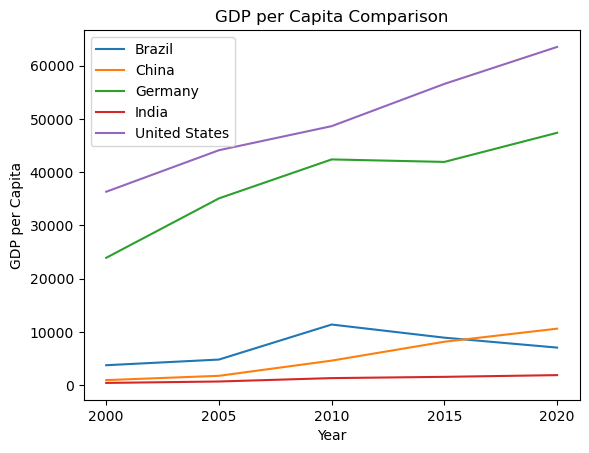

In [5]:
years = ['2000_gdp', '2005_gdp', '2010_gdp', '2015_gdp', '2020_gdp']

for i in range(len(merged)):
    plt.plot(['2000','2005','2010','2015','2020'],
             merged.iloc[i][years],
             label=merged.iloc[i]['Country'])

plt.legend()
plt.title('GDP per Capita Comparison')
plt.xlabel('Year')
plt.ylabel('GDP per Capita')
plt.show()

# GDP per Capita Analysis
# Time-series comparison of economic growth across selected countries.

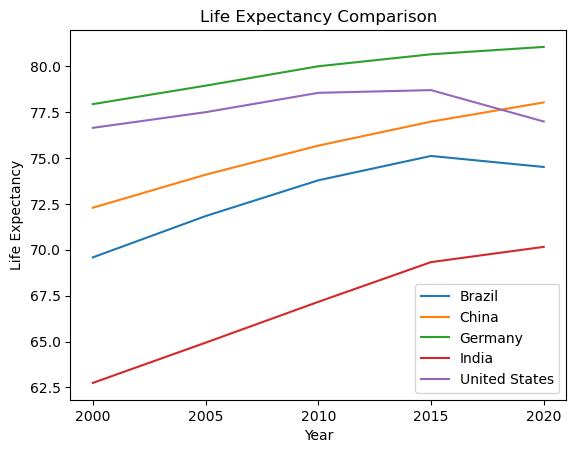

In [6]:
years_life = ['2000_life', '2005_life', '2010_life', '2015_life', '2020_life']

for i in range(len(merged)):
    plt.plot(['2000','2005','2010','2015','2020'],
             merged.iloc[i][years_life],
             label=merged.iloc[i]['Country'])

plt.legend()
plt.title('Life Expectancy Comparison')
plt.xlabel('Year')
plt.ylabel('Life Expectancy')
plt.show()

# Life Expectancy Trends
# Comparison of social development indicators across countries.

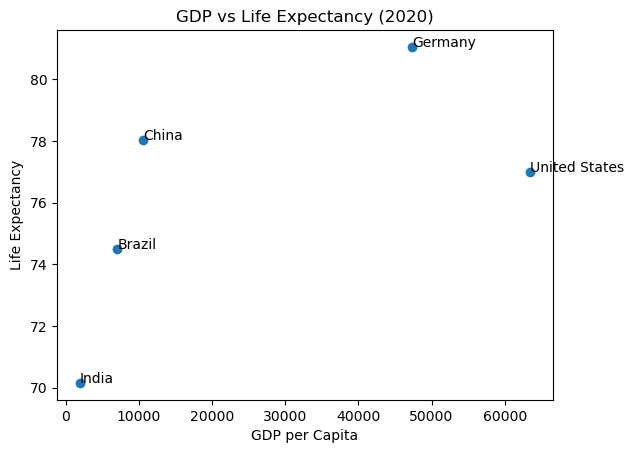

In [7]:
plt.scatter(merged['2020_gdp'], merged['2020_life'])

for i in range(len(merged)):
    plt.text(merged['2020_gdp'].iloc[i],
             merged['2020_life'].iloc[i],
             merged['Country'].iloc[i])

plt.xlabel('GDP per Capita')
plt.ylabel('Life Expectancy')
plt.title('GDP vs Life Expectancy (2020)')
plt.show()

# Relationship Analysis: GDP vs Life Expectancy
# Exploring correlation between economic prosperity and quality of life.

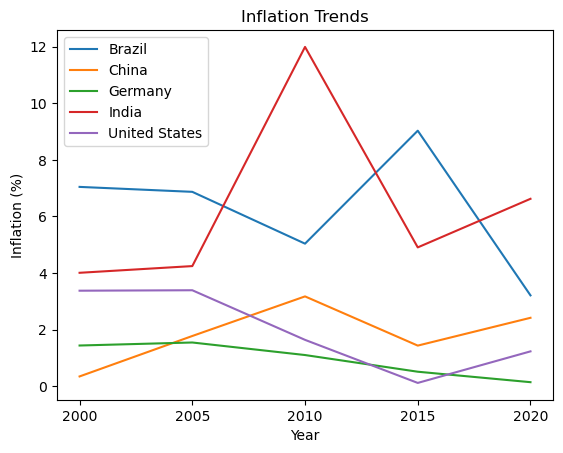

In [8]:
years_inf = ['2000', '2005', '2010', '2015', '2020']

for i in range(len(inflation)):
    plt.plot(years_inf,
             inflation.iloc[i][years_inf],
             label=inflation.iloc[i]['Country'])

plt.legend()
plt.title('Inflation Trends')
plt.xlabel('Year')
plt.ylabel('Inflation (%)')
plt.show()

#  Inflation Trends
# Analysis of economic stability across countries over time.

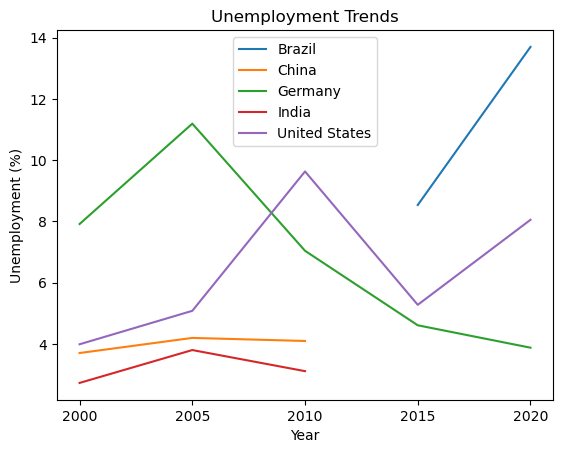

In [9]:
for i in range(len(unemp)):
    plt.plot(years_inf,
             unemp.iloc[i][years_inf],
             label=unemp.iloc[i]['Country'])

plt.legend()
plt.title('Unemployment Trends')
plt.xlabel('Year')
plt.ylabel('Unemployment (%)')
plt.show()

#  Unemployment Trends
# Comparison of labor market conditions across countries.

In [10]:
# Insights

# - Higher GDP per capita is associated with higher life expectancy across countries  
# - Developed countries show more stable inflation and lower unemployment  
# - Developing countries demonstrate higher growth but more volatility  
# - India and China show strong economic growth trends  
# - Economic and social indicators are strongly interconnected  